# Stage 3: Relationships and feature decisions

This notebook looks for relationships that can guide feature engineering and model choice. It uses all rows for description only. No model, scaler, encoder, or learned statistic is fitted here.

The target is `y`: whether the client subscribed to a term deposit. The overall rate expected from the project brief is about 11.7%.

In [9]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Add the project root so this notebook can use the shared data loader.
PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import load_bank

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 30)
bank = load_bank()
bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## Data check

In [10]:
print(f'Rows: {len(bank):,}')
print(f'Columns: {bank.shape[1]}')
print(f'Overall subscription rate: {(bank["y"] == "yes").mean():.3%}')
display(bank.dtypes.to_frame('dtype'))
display(bank['y'].value_counts(dropna=False).to_frame('count'))

Rows: 45,211
Columns: 17
Overall subscription rate: 11.698%


,dtype
age,int64
job,str
marital,str
education,str
default,str
balance,int64
housing,str
loan,str
contact,str
day,int64


,count
y,
no,39922
yes,5289


## Numeric distributions and differences by outcome

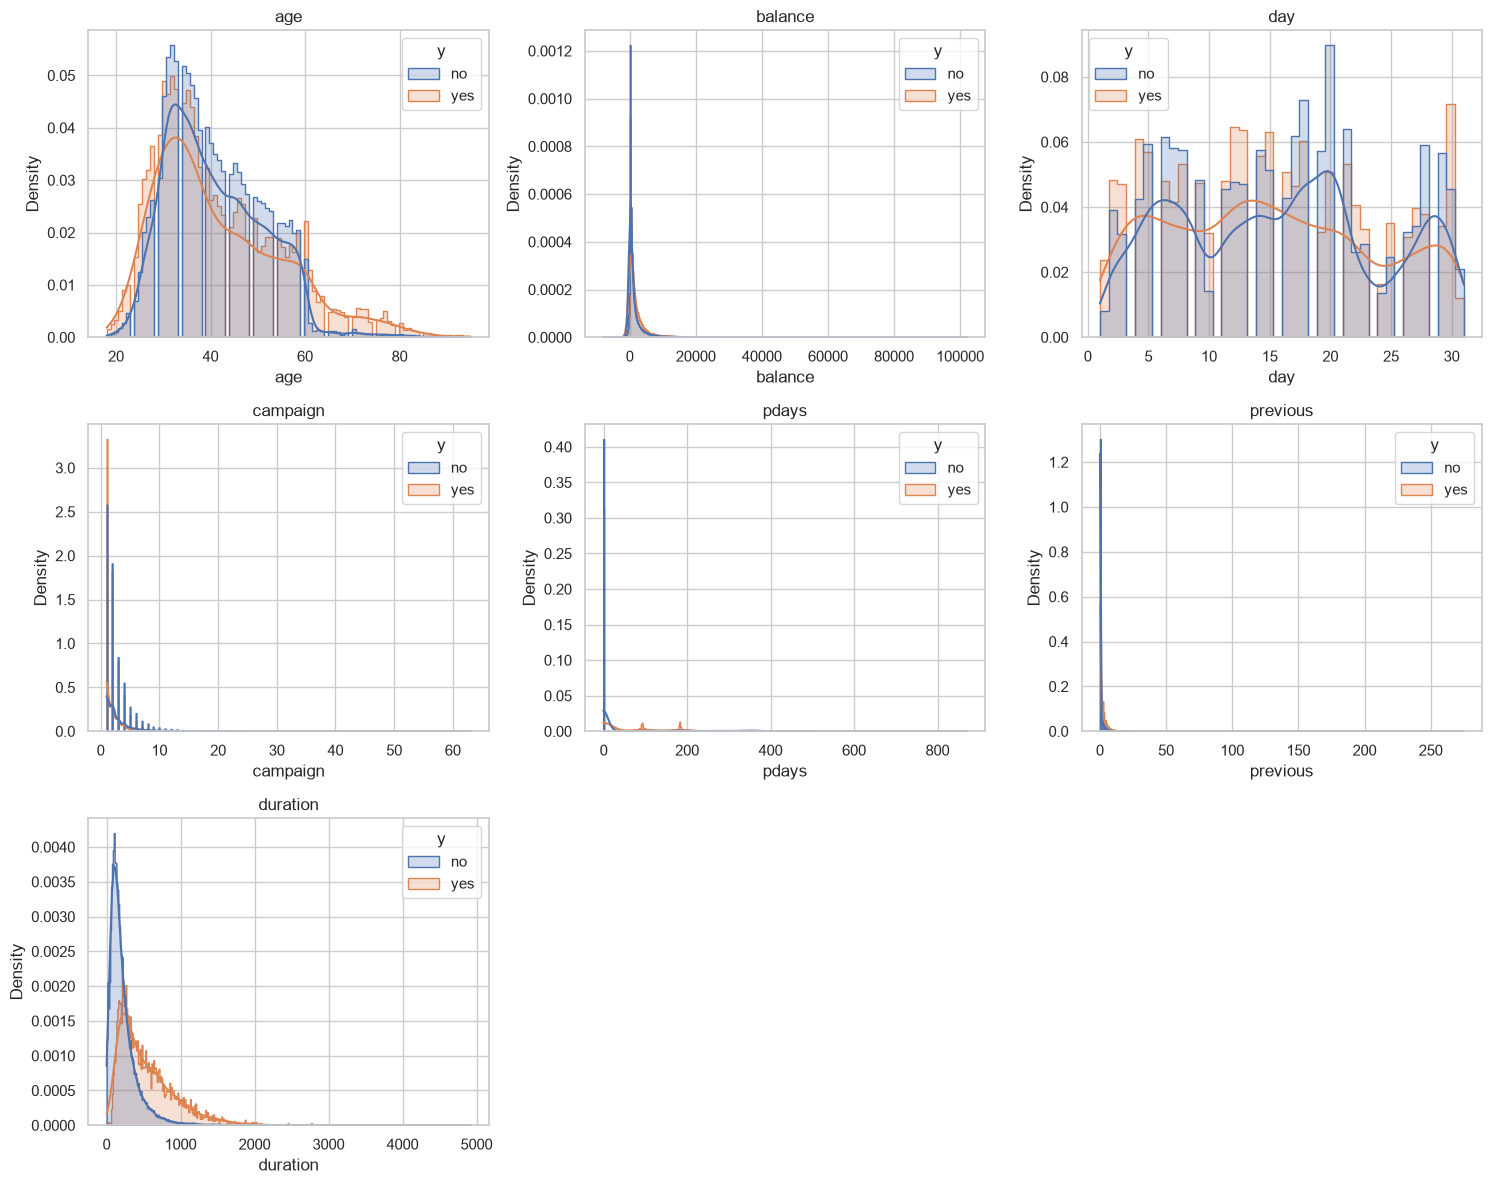

y,no median,yes median
age,39.0,38.0
balance,417.0,733.0
day,16.0,15.0
campaign,2.0,2.0
pdays,-1.0,-1.0
previous,0.0,0.0
duration,164.0,426.0


In [11]:
numeric_features = ['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'duration']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()
for axis, column in zip(axes, numeric_features):
    sns.histplot(data=bank, x=column, hue='y', kde=True, stat='density',
                 common_norm=False, element='step', ax=axis)
    axis.set_title(column)
for axis in axes[len(numeric_features):]:
    axis.set_visible(False)
plt.tight_layout()
plt.show()

display(bank.groupby('y')[numeric_features].median().T.rename(columns={'no': 'no median', 'yes': 'yes median'}))

### Observation and decision
The numeric plots show whether a variable has a visibly different distribution for subscribers and non-subscribers. Large differences are candidates for useful features, but skewed variables such as `balance`, `campaign`, and `duration` should be handled by models or transformations rather than assumed to be normally distributed. `duration` is inspected here only to demonstrate leakage and will not be used as a feature.

## Subscription rate by categorical feature and age group

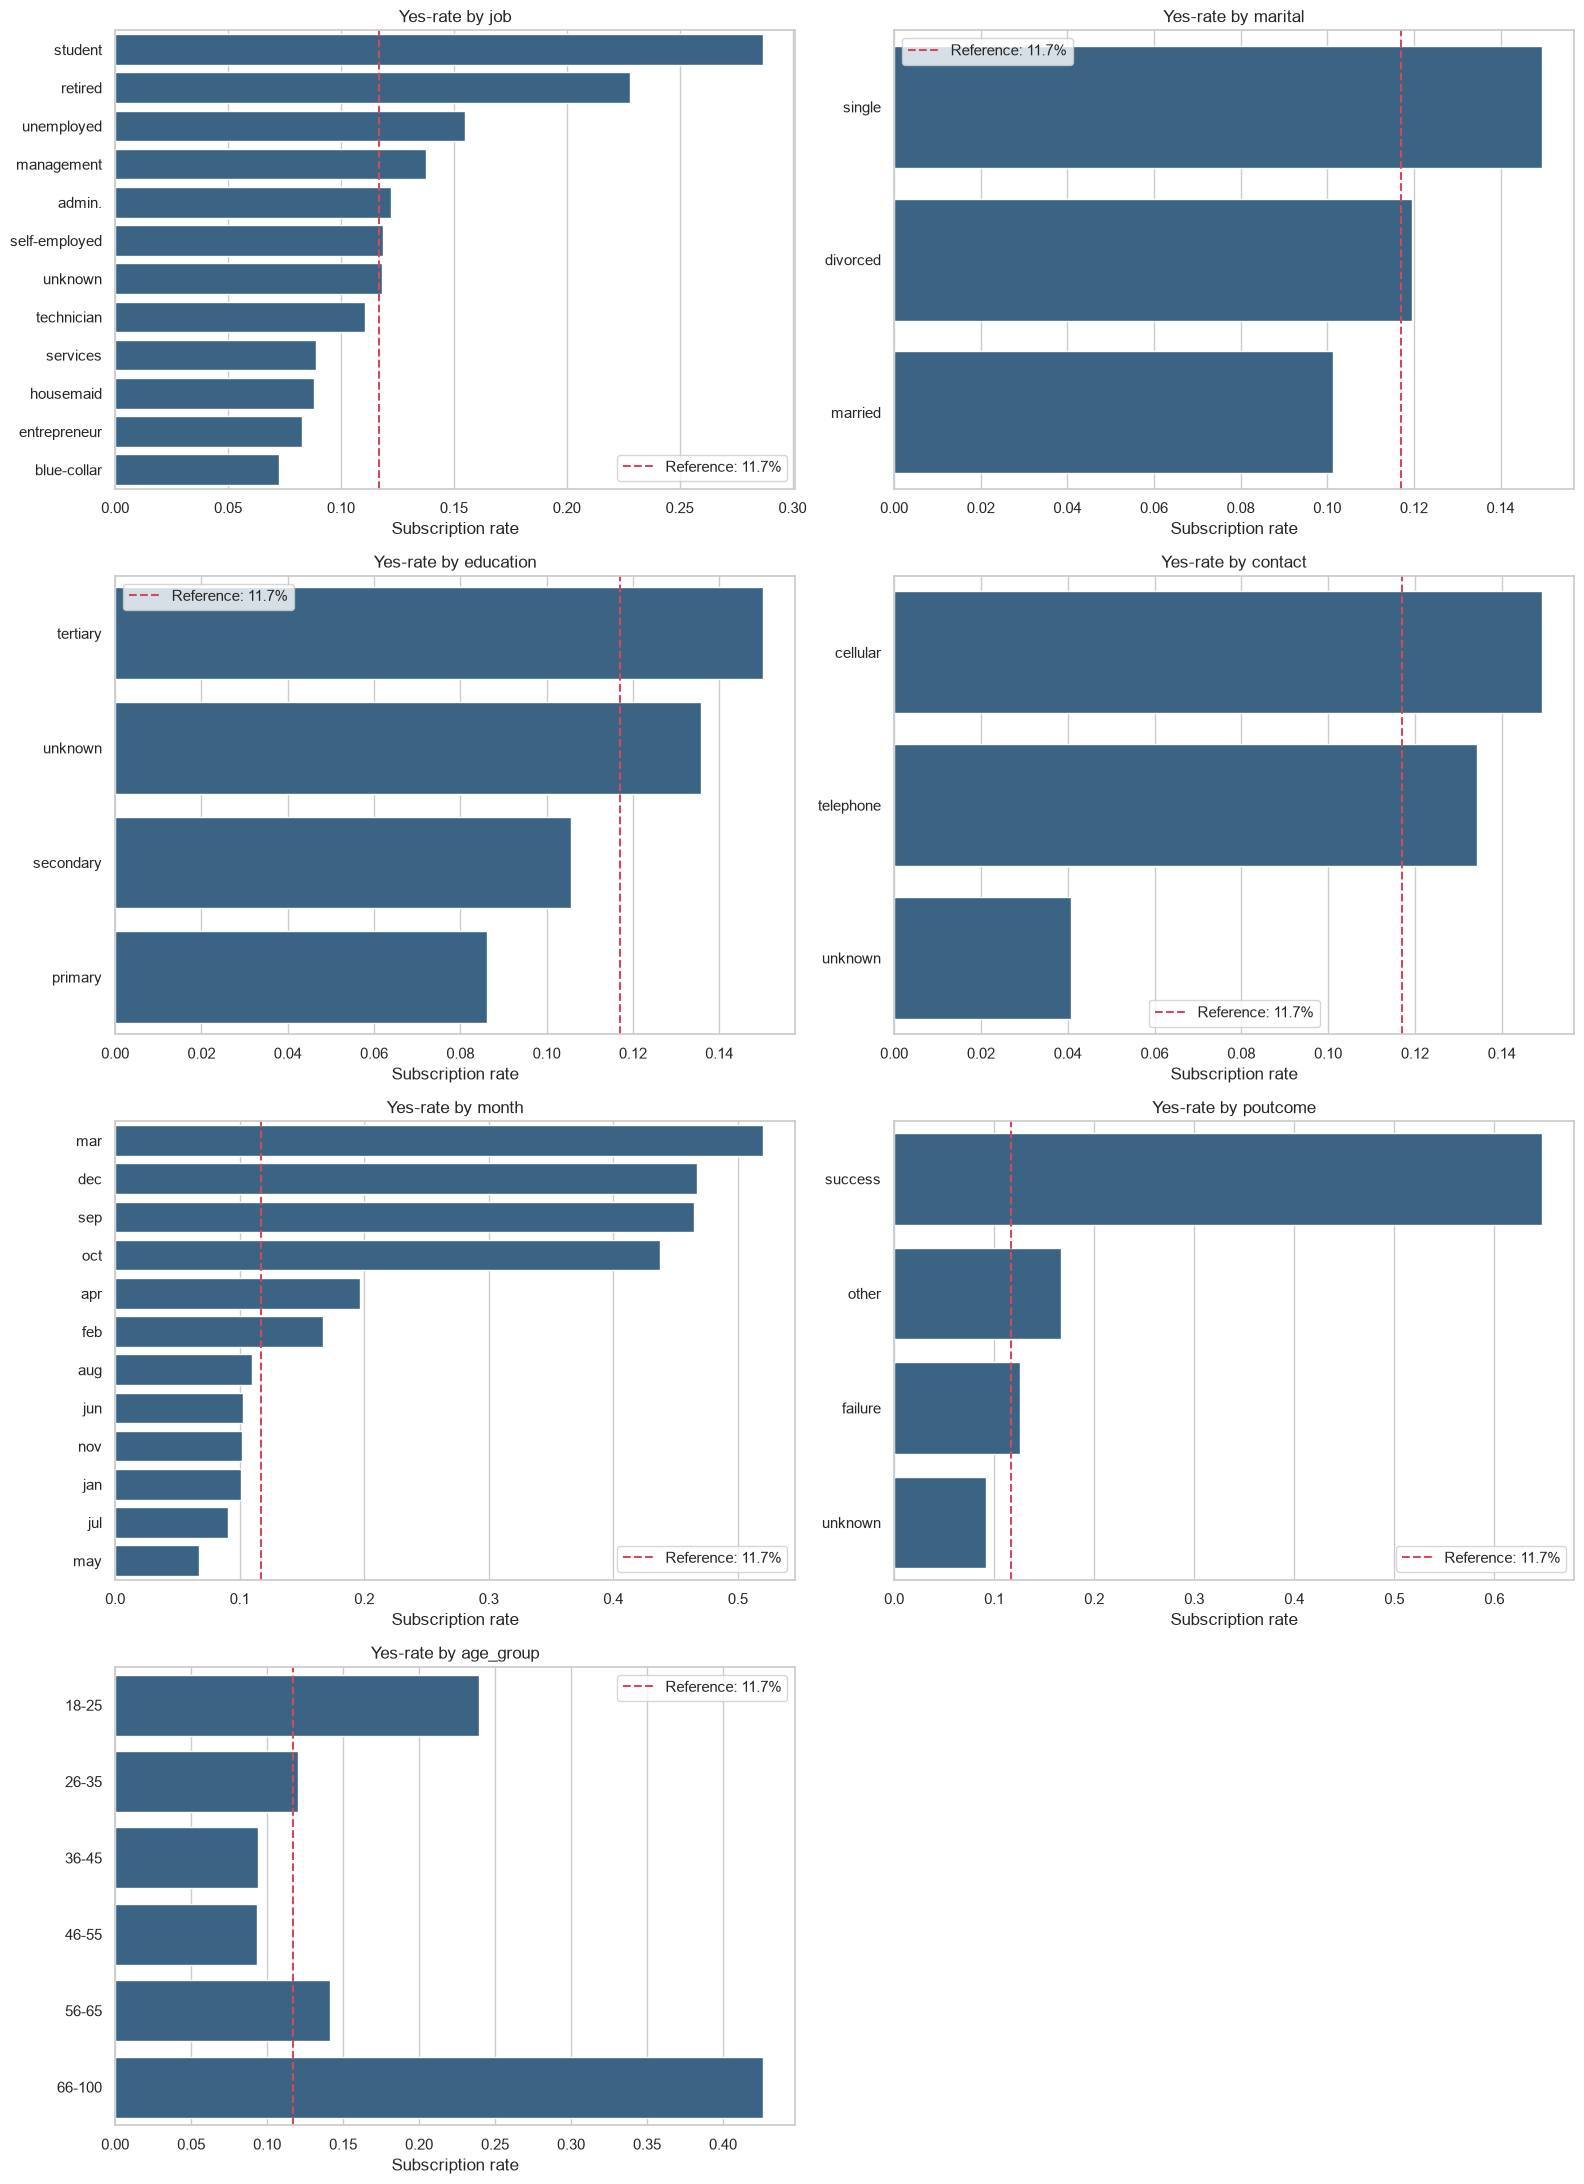

In [12]:
bank['age_group'] = pd.cut(
    bank['age'],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '66-100']
)

rate_columns = ['job', 'marital', 'education', 'contact', 'month', 'poutcome', 'age_group']
overall_rate = (bank['y'] == 'yes').mean()
REFERENCE_RATE = 0.117
fig, axes = plt.subplots(4, 2, figsize=(16, 22))
axes = axes.ravel()
for axis, column in zip(axes, rate_columns):
    rates = (bank.assign(subscribed=bank['y'].eq('yes'))
             .groupby(column, observed=False)['subscribed']
             .mean()
             .sort_values(ascending=False))
    sns.barplot(x=rates.values, y=rates.index, color='#2f6690', ax=axis)
    axis.axvline(REFERENCE_RATE, color='#d1495b', linestyle='--',
                 label='Reference: 11.7%')
    axis.set_title(f'Yes-rate by {column}')
    axis.set_xlabel('Subscription rate')
    axis.set_ylabel('')
    axis.legend()
for axis in axes[len(rate_columns):]:
    axis.set_visible(False)
plt.tight_layout()
plt.show()

### Observation and decision
The dashed line is the overall 11.7% reference rate. Categories well above or below it suggest that the corresponding categorical variable should be retained and one-hot encoded. The spread across months, contact types, outcomes, and jobs also suggests that a model able to combine several small effects may be useful.

## Correlations between numeric features and with the target

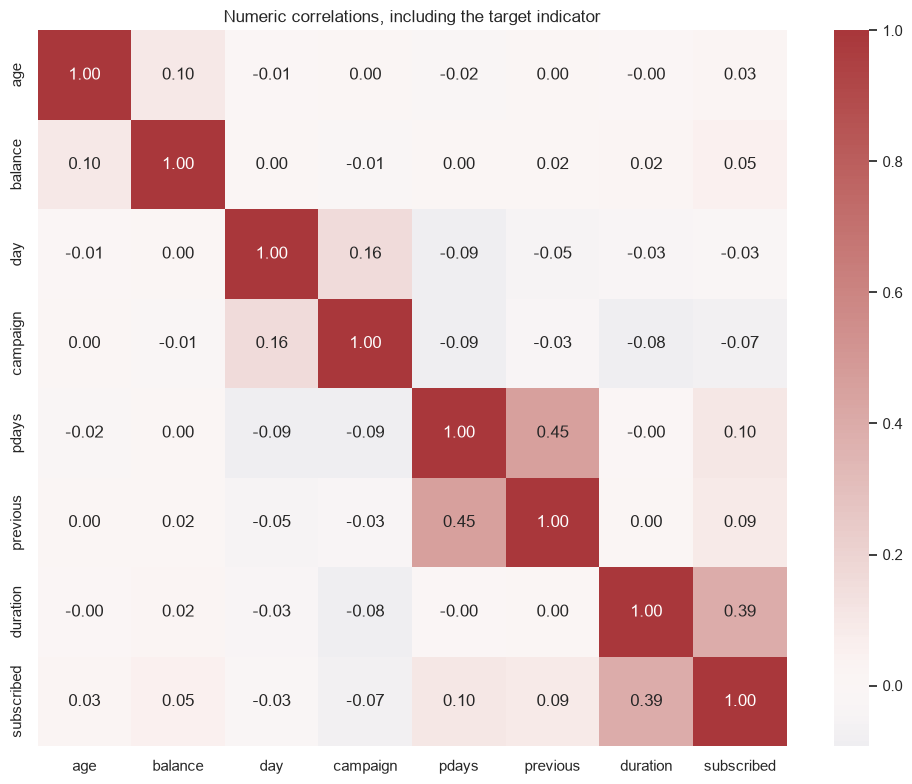

,correlation with subscribed
duration,0.394521
pdays,0.103621
previous,0.093236
balance,0.052838
age,0.025155
day,-0.028348
campaign,-0.073172


In [13]:
# Pearson correlation is a quick linear screen, not a final feature-selection rule.
correlation_data = bank[numeric_features].copy()
correlation_data['subscribed'] = bank['y'].eq('yes').astype(int)
correlation_matrix = correlation_data.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='vlag', center=0)
plt.title('Numeric correlations, including the target indicator')
plt.tight_layout()
plt.show()

display(correlation_matrix['subscribed'].drop('subscribed').sort_values(ascending=False).to_frame('correlation with subscribed'))

### Observation and decision
Correlations close to zero do not prove that a variable is useless because relationships can be nonlinear or conditional on categories. I will keep the allowed numeric campaign-history variables and let cross-validation decide whether they improve PR-AUC, while watching for highly redundant features.

## Interaction 1: month and poutcome

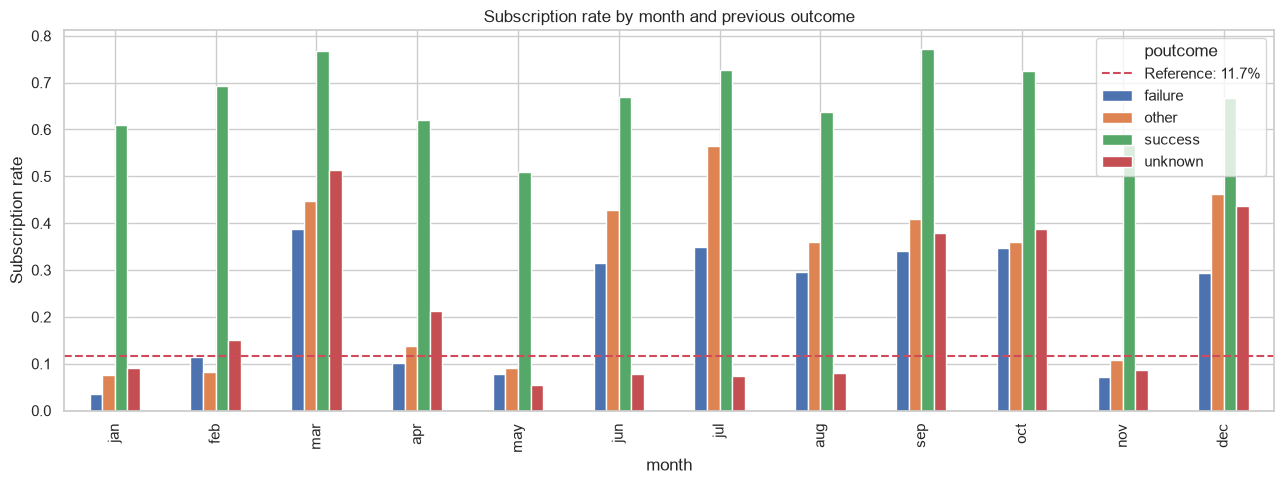

In [14]:
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
month_poutcome = (bank.assign(subscribed=bank['y'].eq('yes'))
                      .pivot_table(index='month', columns='poutcome',
                                  values='subscribed', aggfunc='mean')
                      .reindex(month_order))

month_poutcome.plot(kind='bar', figsize=(13, 5))
plt.axhline(REFERENCE_RATE, color='#d1495b', linestyle='--',
            label='Reference: 11.7%')
plt.ylabel('Subscription rate')
plt.title('Subscription rate by month and previous outcome')
plt.legend(title='poutcome')
plt.tight_layout()
plt.show()

### Observation and decision
If the effect of a month changes across `poutcome` groups, the two variables interact rather than acting independently. This is a reason to compare tree-based models with linear models, because trees can represent useful category combinations without manually creating every interaction.

## Interaction 2: contact and month

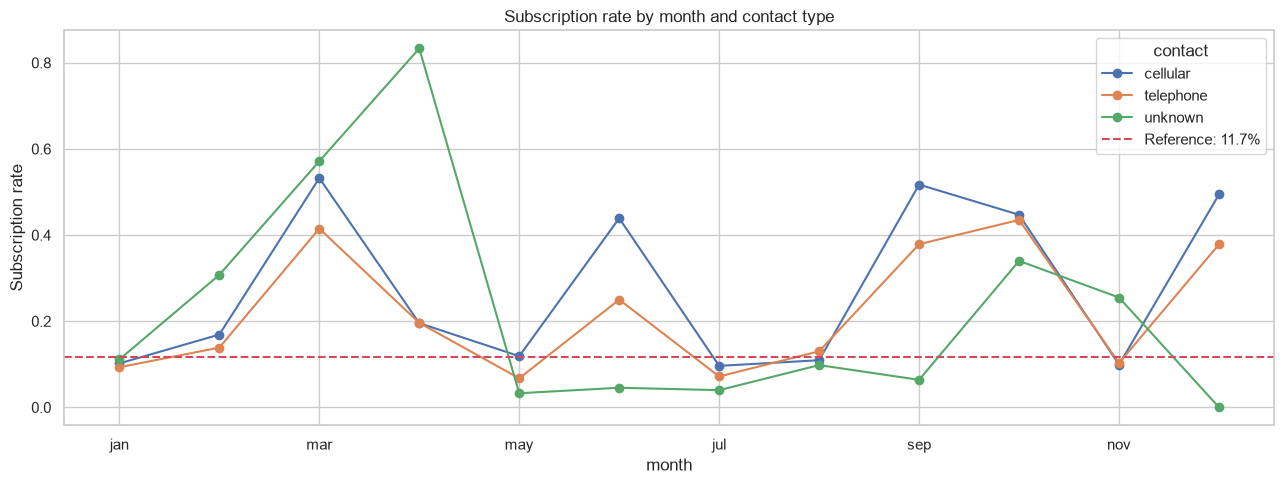

In [15]:
contact_month = (bank.assign(subscribed=bank['y'].eq('yes'))
                 .pivot_table(index='month', columns='contact',
                             values='subscribed', aggfunc='mean')
                 .reindex(month_order))

contact_month.plot(marker='o', figsize=(13, 5))
plt.axhline(REFERENCE_RATE, color='#d1495b', linestyle='--',
            label='Reference: 11.7%')
plt.ylabel('Subscription rate')
plt.title('Subscription rate by month and contact type')
plt.legend(title='contact')
plt.tight_layout()
plt.show()

### Observation and decision
The contact-by-month plot checks whether seasonal patterns depend on how the client was contacted. I will keep both raw categorical variables and compare models using stratified cross-validation rather than trusting a single visual pattern.

## Data leakage: why duration is excluded

In [16]:
duration_summary = (bank.assign(subscribed=bank['y'].eq('yes'))
                    .groupby('y')['duration']
                    .agg(['count', 'median', 'mean']))
display(duration_summary)

duration_target_correlation = bank['duration'].corr(bank['y'].eq('yes').astype(int))
print(f'Correlation between duration and target indicator: {duration_target_correlation:.3f}')

allowed_history = ['campaign', 'pdays', 'previous']
print('Allowed campaign-history fields:', allowed_history)

,count,median,mean
y,,,
no,39922,164.0,221.182806
yes,5289,426.0,537.294574


Correlation between duration and target indicator: 0.395
Allowed campaign-history fields: ['campaign', 'pdays', 'previous']


### Observation and decision
`duration` is measured during the call, so it is not known when the agent needs a call priority. It is also usually strongly linked to `y`, which would make a model look unrealistically good by using information created after the call started. Therefore `duration` must never be a feature.

`campaign`, `pdays`, and `previous` are allowed because they describe campaign history available before the current call. EDA looks at all rows, but nothing is fitted in EDA, so no statistics leak into modelling. The eventual train/test split and preprocessing pipeline must be used for every fitted modelling step.

## Findings to carry into feature engineering and model choice

- Keep the pre-call numeric fields, but exclude `duration` because it is post-call leakage.
- Keep categorical variables such as `poutcome`, `contact`, `month`, `job`, `education`, and `marital`; their yes-rates differ from the overall 11.7% rate.
- Preserve missing or `unknown` category values as explicit categories rather than silently dropping rows.
- Expect skew and nonlinear effects in campaign-history variables, so compare tree-based models with a simple encoded baseline.
- Treat interactions such as month with outcome and contact with month as hypotheses; use stratified cross-validation and PR-AUC to decide whether they improve the model.
- Keep feature engineering inside `src/features.py` and use the same pipeline for training and serving.